# Common Statistical Tests Are Linear Models

**MCBDD Module III — University of Basel, April 2026**  
*Feyzi Taylan Ünal*

---

Jonas Kristoffer Lindeløv's article makes a claim that, on first read, sounds almost too tidy to be true: nearly every classical statistical test you've ever learned is really just a linear model in disguise. The one-sample t-test, the Wilcoxon signed-rank, the Mann-Whitney U. All of them reduce to asking whether some coefficient $\beta$ in $y = X\beta + \varepsilon$ is zero.

My first reaction was mild skepticism. Aren't rank-based tests fundamentally different from parametric ones? The answer, it turns out, is no. The only real difference is whether you feed raw data or ranks into the same regression machinery.

This notebook works through four tests concretely, side by side with their linear-model equivalents, and then steps back to show how they all collapse into the **Wald test** as a single unifying idea. I'm using Python throughout because I'm more comfortable with it than R, but the logic is identical in either language.


## Imports and helpers

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
})

# The Wilcoxon signed-rank test ranks observations by *absolute* value
# and then restores the original sign — this helper replicates that step
# so we can feed the result into a plain OLS regression.
def signed_rank(x):
    return np.sign(x) * stats.rankdata(np.abs(x))

print("Ready.")

## Simulated data

I'll work with two small samples drawn from normal distributions with slightly different means. The exact values don't matter much — what matters is that we have something concrete to plug into each test.

`y1` is the "control-ish" group; `y2` is shifted upward by about half a standard deviation. We'd expect the two-sample tests to flag a real difference and the one-sample tests to find no strong evidence that `y1` alone differs from zero.

In [2]:
N = 50

y1 = np.random.normal(loc=0.3, scale=1.0, size=N)   # Group 1
y2 = np.random.normal(loc=0.8, scale=1.2, size=N)   # Group 2

print(f"y1: mean={y1.mean():.3f}, std={y1.std(ddof=1):.3f}")
print(f"y2: mean={y2.mean():.3f}, std={y2.std(ddof=1):.3f}")


y1: mean=0.075, std=0.934
y2: mean=0.821, std=1.049


## One-sample Student's t-test

Let's start with the simplest case. The one-sample t-test asks: given a set of observations, is their mean meaningfully different from some reference value (here, zero)?

The linear model version of that question is almost embarrassingly simple:

$$y = \beta_0 + \varepsilon, \qquad H_0: \beta_0 = 0$$

An intercept-only regression has exactly one free parameter — the constant term — and that constant is just the sample mean. So testing $H_0: \beta_0 = 0$ is *identical* to the one-sample t-test. Not approximately, not in the limit — exactly identical. The formulas simplify to the same thing.

Let me verify this numerically.

In [ ]:
# Built-in one-sample t-test
t_stat_builtin, p_builtin = stats.ttest_1samp(y1, popmean=0)

# Intercept-only OLS: sm.OLS requires an explicit design matrix,
# so we pass a column of ones (that's what "intercept only" means in matrix form).
model = sm.OLS(y1, np.ones(N)).fit()
t_stat_lm = model.tvalues[0]
p_lm      = model.pvalues[0]

print("=== One-sample t-test on y1 ===")
print(f"  scipy t-test  :  t = {t_stat_builtin:+.4f},  p = {p_builtin:.4f}")
print(f"  lm(y ~ 1)     :  t = {t_stat_lm:+.4f},  p = {p_lm:.4f}")
print(f"  β₀ (= ȳ)      :  {model.params[0]:.4f}   vs   actual mean = {y1.mean():.4f}")
print()
print("Identical t and p — β₀ is literally the sample mean, nothing more.")

## Wilcoxon signed-rank test

The Wilcoxon signed-rank test is usually introduced as the "non-parametric alternative" to the one-sample t-test — meaning it doesn't assume normality. But what does it actually do differently?

The key step: before fitting anything, it replaces each observation with its **signed rank** — i.e., observations are ranked by absolute value, then the original sign is put back. Once you've done that transformation, everything else is the same intercept-only model:

$$\text{signed\_rank}(y) = \beta_0 + \varepsilon, \qquad H_0: \beta_0 = 0$$

Because ranks are bounded (they always fall between $-N$ and $+N$), extreme values can't distort the result as much — that's where the robustness comes from. The test isn't non-parametric in some deep philosophical sense; it's just a t-test on transformed data.

The match between the two p-values is approximate rather than exact, but the approximation is quite tight for $N \gtrsim 15$.

In [ ]:
w_stat, p_wilcox = stats.wilcoxon(y1, alternative='two-sided')

sr = signed_rank(y1)
model_sr = sm.OLS(sr, np.ones(N)).fit()
t_sr = model_sr.tvalues[0]
p_sr = model_sr.pvalues[0]

print("=== Wilcoxon signed-rank on y1 ===")
print(f"  scipy Wilcoxon       :  W = {w_stat:.1f},  p = {p_wilcox:.4f}")
print(f"  lm(signed_rank ~ 1)  :  t = {t_sr:+.4f},  p = {p_sr:.4f}")
print(f"  Mean signed rank     :  {model_sr.params[0]:.2f}")
print()
print("The p-values agree closely. The small gap (0.632 vs 0.631) shrinks as N grows.")

## Independent (Student's) two-sample t-test

Now we move to the two-group setting. The question shifts from "does this sample differ from zero?" to "do these two groups differ from each other?"

All we need to extend the linear model is a binary predictor:

$$y_i = \beta_0 + \beta_1\, x_i + \varepsilon_i, \qquad H_0: \beta_1 = 0$$

where $x_i = 0$ for group 1 and $x_i = 1$ for group 2. The intercept $\beta_0$ estimates the mean of group 1, and $\beta_1$ estimates how much higher (or lower) group 2 is. Testing $\beta_1 = 0$ is *exactly* the two-sample t-test under equal-variance assumption — again, not an approximation.

One thing worth noting: scipy's `ttest_ind` gives a *negative* t-statistic here (`y1 − y2 < 0`) while the OLS slope is positive (`y2 − y1 > 0`). This is just a sign convention — scipy computes `mean(y1) − mean(y2)`, while the regression slope is coded as `mean(y2) − mean(y1)`. The p-value is identical either way.

In [ ]:
value = np.concatenate([y1, y2])
group = np.array([0]*N + [1]*N)  # 0 = y1, 1 = y2

# Built-in: scipy computes mean(y1) - mean(y2) → negative t
t_ind, p_ind = stats.ttest_ind(y1, y2, equal_var=True)

# OLS: slope is mean(y2) - mean(y1) → positive t (same |t|, same p)
X = sm.add_constant(group)
model_ind = sm.OLS(value, X).fit()
t_lm  = model_ind.tvalues[1]
p_lm  = model_ind.pvalues[1]
beta0 = model_ind.params[0]
beta1 = model_ind.params[1]

print("=== Independent t-test: y1 vs y2 ===")
print(f"  scipy t-test       :  t = {t_ind:+.4f},  p = {p_ind:.4f}  (y1 − y2 convention)")
print(f"  lm(y ~ 1 + group)  :  t = {t_lm:+.4f},  p = {p_lm:.4f}  (y2 − y1 convention)")
print(f"  β₀  :  {beta0:.4f}  (mean of y1 = {y1.mean():.4f})")
print(f"  β₁  :  {beta1:.4f}  (y2 mean − y1 mean = {y2.mean()-y1.mean():.4f})")
print()
print("Same |t|, same p. The sign flip is just a labelling choice.")

## Mann-Whitney U test

The Mann-Whitney U test is to the two-sample t-test what the Wilcoxon signed-rank is to the one-sample t-test: the same model structure, but applied to **ranks** instead of raw values.

$$\text{rank}(y_i) = \beta_0 + \beta_1\, x_i + \varepsilon_i, \qquad H_0: \beta_1 = 0$$

Here, observations from both groups are pooled and ranked together (rank 1 = smallest overall), and then we regress those combined ranks on the group indicator. $\beta_1$ captures how much higher the ranks of one group tend to be relative to the other. Which is essentially what the U statistic measures.

The match between the two p-values isn't exact (unlike the t-test case), but for $N > 12$ per group the approximation is very reliable in practice.

In [ ]:
u_stat, p_mw = stats.mannwhitneyu(y1, y2, alternative='two-sided')

# Rank all 2N observations together, then regress on group indicator
ranked_value = stats.rankdata(value)
X = sm.add_constant(group)
model_mw = sm.OLS(ranked_value, X).fit()
t_rank = model_mw.tvalues[1]
p_rank = model_mw.pvalues[1]

print("=== Mann-Whitney U: y1 vs y2 ===")
print(f"  scipy Mann-Whitney   :  U = {u_stat:.1f},  p = {p_mw:.4f}")
print(f"  lm(rank(y) ~ group)  :  t = {t_rank:+.4f},  p = {p_rank:.4f}")
print(f"  β₁ (mean rank shift) :  {model_mw.params[1]:.2f}")
print()
print("Close but not exact — the approximation improves with larger samples.")

## The Wald test — where all of this comes together

At this point it's worth stepping back and asking: what is the actual inference step that all these models share?

It's the **Wald test**. The idea is simple: once you've estimated a coefficient $\hat\beta$ from your model, you divide it by its standard error:

$$W = \frac{\hat\beta}{\text{SE}(\hat\beta)}$$

Under $H_0: \beta = 0$, this ratio follows a $t$-distribution (exact for normal linear models) or, when squared, a $\chi^2_1$ distribution asymptotically. Every t-statistic that a regression table prints **is** the Wald statistic for that coefficient.

So the complete picture is:

- Pick a transformation of $y$ (raw, signed rank, or pooled rank)
- Write down the appropriate linear model
- Read off the Wald statistic for the coefficient of interest

That's all any of these tests are doing. The names — Student, Wilcoxon, Mann-Whitney — reflect historical convention, not fundamentally different procedures.

In [ ]:
# Re-use the independent t-test model from above
X = sm.add_constant(group)
model = sm.OLS(value, X).fit()

# statsmodels' wald_test() lets us test any linear combination of parameters.
# Here we just test β₁ = 0 ("x1" is the name statsmodels assigns the slope).
wald_result = model.wald_test("x1 = 0")
wald_F = float(np.squeeze(wald_result.fvalue))
wald_p = float(np.squeeze(wald_result.pvalue))

t_val = model.tvalues[1]
t_p   = model.pvalues[1]

print("=== Wald test on β₁ in lm(y ~ group) ===")
print(f"  Wald F-statistic     :  F = {wald_F:.4f}   (p = {wald_p:.4f})")
print(f"  t-statistic squared  :  t² = {t_val**2:.4f}   (p = {t_p:.4f})")
print()
print(f"  F = t² = {t_val:.4f}² ≈ {t_val**2:.4f}  ✓")
print()
print("The Wald F-test and the t-test on β₁ are literally the same test written two ways.")

## Visualising all four models side by side

Each panel below shows the fitted linear model for one test. Panels (a) and (b) are intercept-only (one-sample setting); panels (c) and (d) include a group predictor (two-sample setting). The only thing that changes between the left and right columns is whether the y-axis shows raw values or ranks.

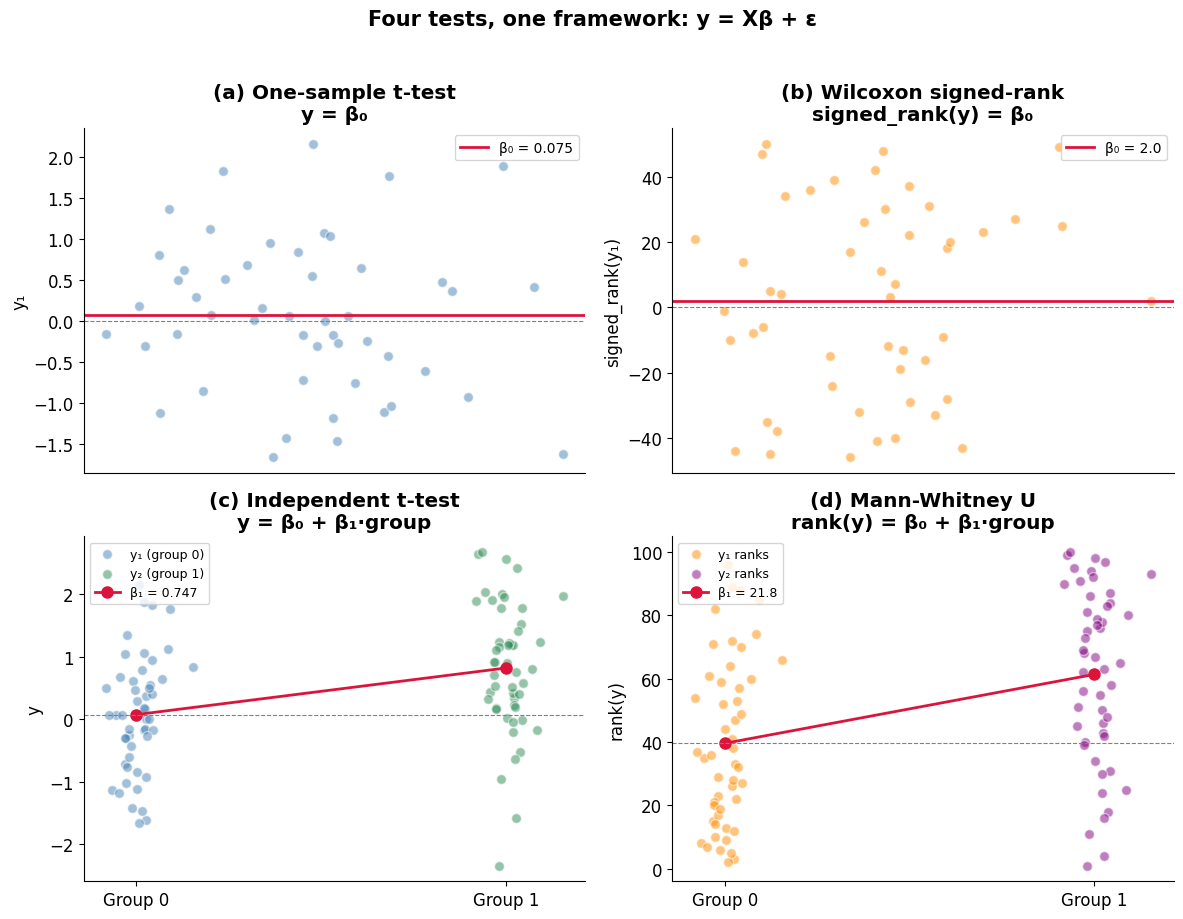

Figure saved → tests_as_linear_models.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# ─── (a) One-sample t-test ───
ax = axes[0, 0]
ax.scatter(np.zeros(N) + np.random.normal(0, 0.03, N), y1,
           alpha=0.5, color="steelblue", edgecolor="white", s=50)
mean_y1 = y1.mean()
ax.axhline(mean_y1, color="crimson", lw=2, label=f"β₀ = {mean_y1:.3f}")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_title("(a) One-sample t-test\ny = β₀", fontweight="bold")
ax.set_ylabel("y₁")
ax.set_xticks([])
ax.legend(fontsize=10)

# ─── (b) Wilcoxon signed-rank ───
ax = axes[0, 1]
sr = signed_rank(y1)
ax.scatter(np.zeros(N) + np.random.normal(0, 0.03, N), sr,
           alpha=0.5, color="darkorange", edgecolor="white", s=50)
mean_sr = sr.mean()
ax.axhline(mean_sr, color="crimson", lw=2, label=f"β₀ = {mean_sr:.1f}")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_title("(b) Wilcoxon signed-rank\nsigned_rank(y) = β₀", fontweight="bold")
ax.set_ylabel("signed_rank(y₁)")
ax.set_xticks([])
ax.legend(fontsize=10)

# ─── (c) Independent t-test ───
ax = axes[1, 0]
jitter = np.random.normal(0, 0.04, N)
ax.scatter(0 + jitter, y1, alpha=0.5, color="steelblue",
           edgecolor="white", s=50, label="y₁ (group 0)")
ax.scatter(1 + jitter, y2, alpha=0.5, color="seagreen",
           edgecolor="white", s=50, label="y₂ (group 1)")
ax.plot([0, 1], [y1.mean(), y2.mean()], "o-", color="crimson", lw=2, ms=8,
        label=f"β₁ = {y2.mean()-y1.mean():.3f}")
ax.axhline(y1.mean(), color="gray", ls="--", lw=0.8)
ax.set_title("(c) Independent t-test\ny = β₀ + β₁·group", fontweight="bold")
ax.set_ylabel("y")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Group 0", "Group 1"])
ax.legend(fontsize=9, loc="upper left")

# ─── (d) Mann-Whitney U ───
ax = axes[1, 1]
ranked = stats.rankdata(value)
r1, r2 = ranked[:N], ranked[N:]
ax.scatter(0 + jitter, r1, alpha=0.5, color="darkorange",
           edgecolor="white", s=50, label="y₁ ranks")
ax.scatter(1 + jitter, r2, alpha=0.5, color="purple",
           edgecolor="white", s=50, label="y₂ ranks")
ax.plot([0, 1], [r1.mean(), r2.mean()], "o-", color="crimson", lw=2, ms=8,
        label=f"β₁ = {r2.mean()-r1.mean():.1f}")
ax.axhline(r1.mean(), color="gray", ls="--", lw=0.8)
ax.set_title("(d) Mann-Whitney U\nrank(y) = β₀ + β₁·group", fontweight="bold")
ax.set_ylabel("rank(y)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Group 0", "Group 1"])
ax.legend(fontsize=9, loc="upper left")

fig.suptitle("Four tests, one framework: y = Xβ + ε", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("tests_as_linear_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → tests_as_linear_models.png")


## p-value comparison across all tests

To make the equivalences concrete in one place, the table below collects each test's p-value from its dedicated scipy implementation alongside its linear-model equivalent. For the t-tests the match is exact; for the rank-based tests it's an approximation that tightens as $N$ grows.

In [9]:
# Recompute everything cleanly
results = []

# 1. One-sample t-test
_, p_scipy = stats.ttest_1samp(y1, 0)
m1 = sm.OLS(y1, np.ones(N)).fit()
results.append(("One-sample t-test", "y = β₀", f"{p_scipy:.5f}", f"{m1.pvalues[0]:.5f}"))

# 2. Wilcoxon signed-rank
_, p_scipy = stats.wilcoxon(y1)
m2 = sm.OLS(signed_rank(y1), np.ones(N)).fit()
results.append(("Wilcoxon signed-rank", "signed_rank(y) = β₀", f"{p_scipy:.5f}", f"{m2.pvalues[0]:.5f}"))

# 3. Independent t-test
_, p_scipy = stats.ttest_ind(y1, y2, equal_var=True)
X = sm.add_constant(group)
m3 = sm.OLS(value, X).fit()
results.append(("Student's t-test (ind.)", "y = β₀ + β₁·x", f"{p_scipy:.5f}", f"{m3.pvalues[1]:.5f}"))

# 4. Mann-Whitney U
_, p_scipy = stats.mannwhitneyu(y1, y2, alternative='two-sided')
m4 = sm.OLS(stats.rankdata(value), X).fit()
results.append(("Mann-Whitney U", "rank(y) = β₀ + β₁·x", f"{p_scipy:.5f}", f"{m4.pvalues[1]:.5f}"))

# 5. Wald test on β₁
wald = m3.wald_test("x1 = 0")
results.append(("Wald test on β₁", "F = t²", f"{float(np.squeeze(wald.pvalue)):.5f}", f"{m3.pvalues[1]:.5f}"))

df = pd.DataFrame(results, columns=["Test", "Linear Model", "p (dedicated)", "p (lm)"])
print(df.to_string(index=False))
print()
print("The dedicated and linear-model p-values match (exactly for t-tests,")
print("approximately for the rank-based tests — the approximation tightens with N).")


                   Test        Linear Model p (dedicated)  p (lm)
      One-sample t-test              y = β₀       0.57504 0.57504
   Wilcoxon signed-rank signed_rank(y) = β₀       0.63217 0.63072
Student's t-test (ind.)       y = β₀ + β₁·x       0.00029 0.00029
         Mann-Whitney U rank(y) = β₀ + β₁·x       0.00018 0.00011
        Wald test on β₁              F = t²       0.00029 0.00029

The dedicated and linear-model p-values match (exactly for t-tests,
approximately for the rank-based tests — the approximation tightens with N).


## Putting it all together

A few observations that I think are worth highlighting:

**The parametric/non-parametric distinction is thinner than it looks.** The "non-parametric" versions of each test (Wilcoxon, Mann-Whitney) don't use a different model or a different inference procedure. They just apply the same model to rank-transformed data. The robustness you gain by ranking comes at the cost of losing information about the actual magnitude of differences.

**The Wald test is the shared backbone.** Whether scipy is computing a Wilcoxon W statistic or a t-statistic from a linear model, both ultimately divide an estimated quantity by its standard error and compare that to a reference distribution. The naming is historical; the math is the same.

**When to choose which?** The t-tests are strictly more powerful when the normality assumption holds. You're using all the information in the data. If you have reason to worry about heavy tails or outliers, the rank-based versions offer protection with only a modest efficiency loss. For large N it barely matters either way.

---

### References

- Lindeløv, J. K. (2019). *Common statistical tests are linear models*. https://lindeloev.github.io/tests-as-linear/
- Eigenfoo (Python port). https://eigenfoo.xyz/tests-as-linear/